# 🇪🇬 Adaptive Egyptian Arabic Audio Preprocessing Pipeline

This notebook provides an interactive validation and analysis suite for the audio preprocessing pipeline. 

## Phase 1: Data Exploration & Initial Analysis
Analyze the distribution of audio durations and transcriptions in `cut_clips9`.

In [36]:
%load_ext autoreload
%autoreload 2

import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import IPython.display as ipd
import librosa.display
import random

# Add project root to sys.path
sys.path.append(os.path.abspath('.'))

from analysis.data_explorer import DataExplorer
from pipeline import AdaptivePipeline
from utils.audio_io import AudioIO

# Constants - Using relative paths for portability
PROJECT_ROOT = os.path.abspath('..')
AUDIO_DIR = os.path.join(PROJECT_ROOT, "cut_clips9")
TRANS_DIR = os.path.join(PROJECT_ROOT, "cut_clips9_transcriptions")

print(f"Project Root: {PROJECT_ROOT}")
print(f"Audio Dir exists: {os.path.exists(AUDIO_DIR)} ({AUDIO_DIR})")
print(f"Trans Dir exists: {os.path.exists(TRANS_DIR)} ({TRANS_DIR})")

explorer = DataExplorer(AUDIO_DIR, TRANS_DIR)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project Root: d:\study\4th year 2nd term\NLP\Project 2 - Audio
Audio Dir exists: True (d:\study\4th year 2nd term\NLP\Project 2 - Audio\cut_clips9)
Trans Dir exists: True (d:\study\4th year 2nd term\NLP\Project 2 - Audio\cut_clips9_transcriptions)
DEBUG: Searching for audio in: d:\study\4th year 2nd term\NLP\Project 2 - Audio\cut_clips9\*.wav
DEBUG: Found 7502 audio files.
DEBUG: Searching for transcripts in: d:\study\4th year 2nd term\NLP\Project 2 - Audio\cut_clips9_transcriptions\*.txt
DEBUG: Found 7502 transcript files.


### 1. Audio Duration Analysis

Analyzing 7502 audio files...


100%|██████████| 7502/7502 [01:02<00:00, 120.18it/s]


,duration_sec
count,7502.000000
mean,1.960436
std,0.691643
min,0.020590
25%,1.400023
50%,2.000000
75%,2.480000
max,4.760000


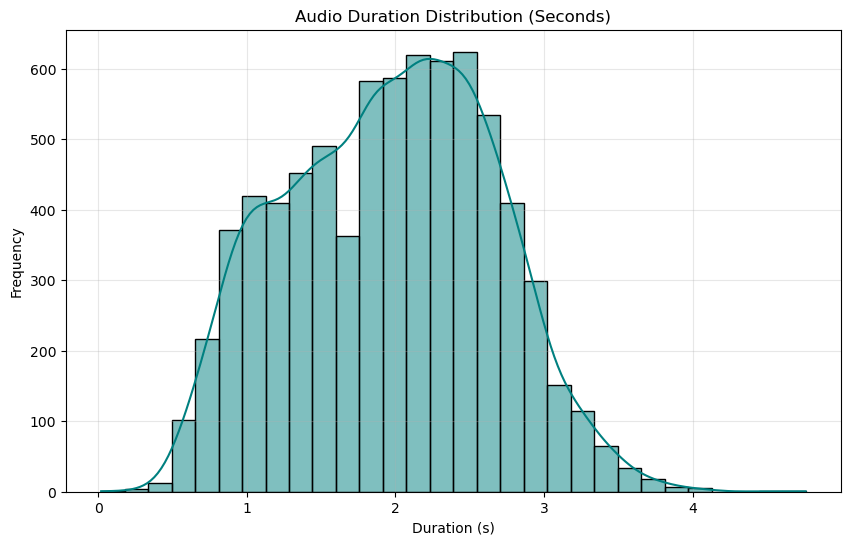

In [ ]:
audio_df = explorer.analyze_audio_durations()
if audio_df.empty:
    print("No audio files found. Please check if the AUDIO_DIR path is correct above.")
else:
    display(audio_df.describe())

    # Plotting distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(audio_df['duration_sec'], bins=30, kde=True, color='teal')
    plt.title('Audio Duration Distribution (Seconds)')
    plt.xlabel('Duration (s)')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    plt.show()

### 2. Transcription Text Analysis

Analyzing 7502 transcriptions...


100%|██████████| 7502/7502 [00:51<00:00, 146.54it/s]


,word_count,char_count
count,7502.000000,7502.000000
mean,4.900293,26.832845
std,1.807324,9.841230
min,0.000000,0.000000
25%,3.000000,19.000000
50%,5.000000,28.000000
75%,6.000000,35.000000
max,11.000000,54.000000


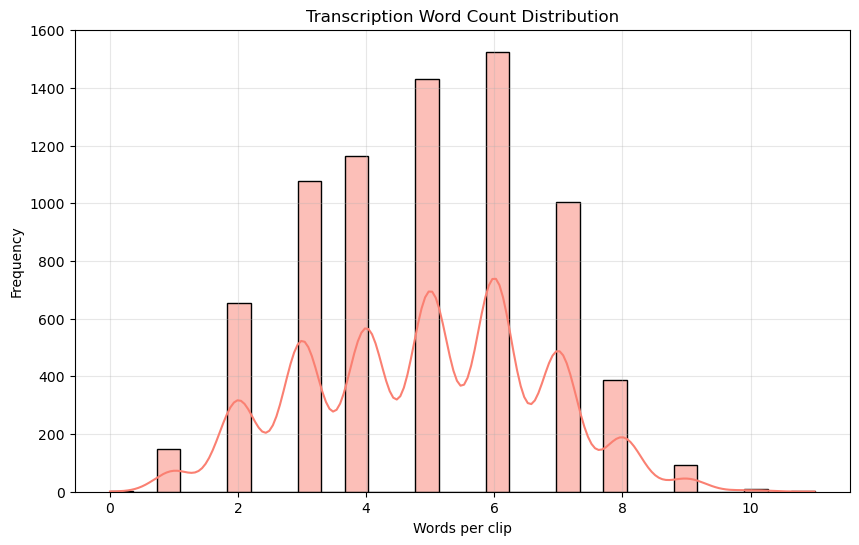

In [38]:
transcript_df = explorer.analyze_transcriptions()
if transcript_df.empty:
    print("No transcriptions found. Please check if the TRANS_DIR path is correct above.")
else:
    display(transcript_df.describe())

    # Word count distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(transcript_df['word_count'], bins=30, kde=True, color='salmon')
    plt.title('Transcription Word Count Distribution')
    plt.xlabel('Words per clip')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    plt.show()

### 3. Corpus Integrity Check

In [39]:
integrity = explorer.check_integrity(audio_df, transcript_df)
print("Corpus Integrity Report:")
for key, value in integrity.items():
    if isinstance(value, list):
        print(f"{key}: {len(value)} files")
    else:
        print(f"{key}: {value}")

Corpus Integrity Report:
total_audio: 7502
total_transcripts: 7502
matched_count: 7502
missing_audio_files: 0 files
missing_transcript_files: 0 files


## Phase 2: Pipeline Validation & Step-by-Step Testing

Run this section to test the adaptive pipeline on **random** samples.

In [40]:
pipeline = AdaptivePipeline()
print("Pipeline initialized.")

⚠️ Warning: Could not load Neural VAD due to environment error: Could not find module 'C:\Users\Mahmoud\anaconda3\Lib\site-packages\torchaudio\lib\libtorchaudio.pyd' (or one of its dependencies). Try using the full path with constructor syntax.
⚙️ Falling back to Energy-Based VAD.
Pipeline initialized.


Using cache found in C:\Users\Mahmoud/.cache\torch\hub\snakers4_silero-vad_master


### Stage A: Adaptive Processing (Run this repeatedly for Variety)

In [41]:
if not explorer.audio_files:
    print("No audio files loaded in explorer.")
else:
    # Pick a RANDOM file every time this cell is run
    sample_wav = random.choice(explorer.audio_files)
    print(f"\n🔍 Testing with: {os.path.basename(sample_wav)}")
    
    res = pipeline.process_file(sample_wav)
    
    if res['status'] == 'success':
        print("="*40)
        print(f"PASS: {res['file_name']}")
        print(f"Assigned Tier: {res['tier']}")
        print(f"SNR Change: {res['pre_snr']} dB -> {res['post_snr']} dB")
        print(f"Segments Found: {res['segments_count']}")
    else:
        print(f"FAILED: {res['file_name']}")
        print(f"Error: {res['report']['errors']}")


🔍 Testing with: ARA NORM 18044.wav
PASS: ARA NORM 18044.wav
Assigned Tier: EXCELLENT
SNR Change: 31.45 dB -> 32.14 dB
Segments Found: 1


### Stage B: Visualizing Processing (Before vs After)
Comparing Waveforms and Spectrograms for the last processed sample.

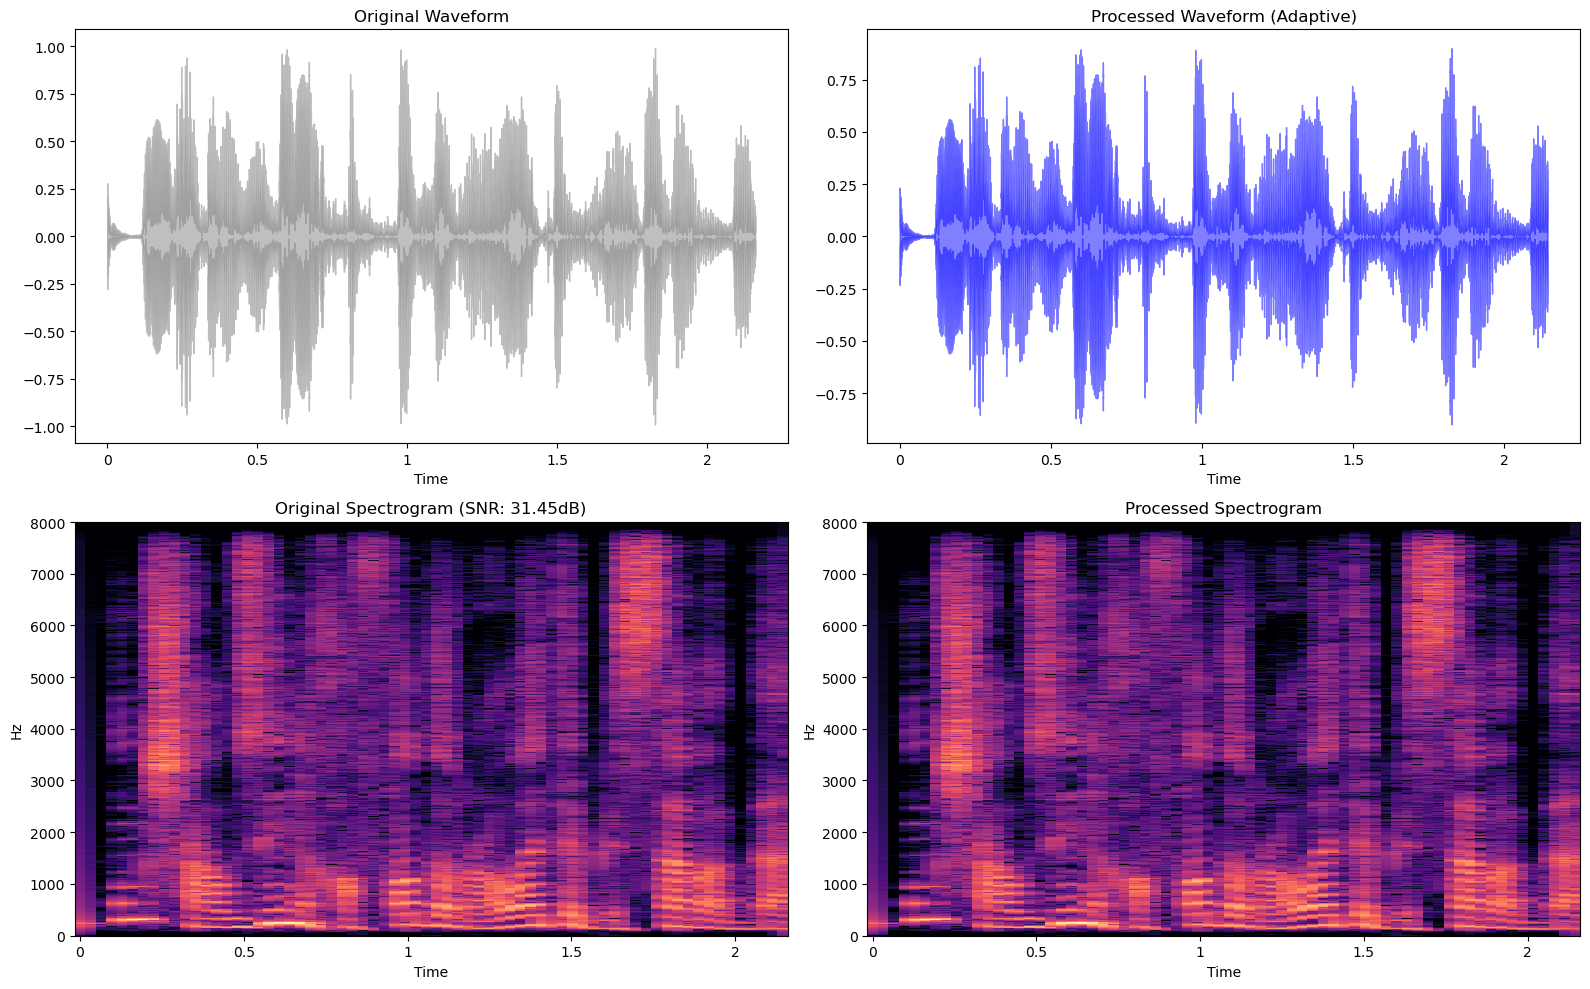

Original Audio:


Processed Audio:


In [42]:
if 'sample_wav' in locals() and res['status'] == 'success':
    audio, sr = AudioIO.load(sample_wav, target_sr=pipeline.config.target_sr)
    quality = pipeline.scorer.get_quality_report(audio)
    tier_cfg = pipeline.config.tiers[quality['quality_tier']]

    # Re-run logic for manual visualization access
    clean_audio = pipeline.denoizer.denoise(audio, sr, reduction_factor=tier_cfg.denoise_factor)
    norm_audio = pipeline.normalizer.process(clean_audio, method=tier_cfg.norm_method)

    fig, ax = plt.subplots(2, 2, figsize=(16, 10))

    # Waveforms
    librosa.display.waveshow(audio, sr=sr, ax=ax[0, 0], color='gray', alpha=0.5)
    ax[0, 0].set_title("Original Waveform")

    librosa.display.waveshow(norm_audio, sr=sr, ax=ax[0, 1], color='blue', alpha=0.5)
    ax[0, 1].set_title("Processed Waveform (Adaptive)")

# Spectrograms
    D_orig = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
    img1 = librosa.display.specshow(D_orig, sr=sr, x_axis='time', y_axis='hz', ax=ax[1, 0])
    ax[1, 0].set_title(f"Original Spectrogram (SNR: {quality['snr_db']}dB)")

    D_prep = librosa.amplitude_to_db(np.abs(librosa.stft(norm_audio)), ref=np.max)
    img2 = librosa.display.specshow(D_prep, sr=sr, x_axis='time', y_axis='hz', ax=ax[1, 1])
    ax[1, 1].set_title("Processed Spectrogram")

    plt.tight_layout()
    plt.show()

    print("Original Audio:")
    ipd.display(ipd.Audio(audio, rate=sr))
    print("Processed Audio:")
    ipd.display(ipd.Audio(norm_audio, rate=sr))
else:
    print("No sample processed or processing failed. Run the 'Stage A' cell above.")